In [45]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import umap
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
INPUT = "/home/ensai/Cours/PFE/Topic-modeling-with-NLP/data/makeorg_biodiversite.xlsx" # Path to the dataset

df = pd.read_excel(INPUT)
texts = df['Proposition'].tolist()

In [47]:
# Option 1: all-MiniLM-L6-v2 (plus léger et rapide)
# model = SentenceTransformer('all-MiniLM-L6-v2')

# 'Qwen/Qwen3-Embedding-0.6B'

# Option 2: mpnet-base-v2 
# This is a sentence-transformers model: 
# It maps sentences & paragraphs to a 768 dimensional dense vector space and can be used for tasks like clustering or semantic search
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

embeddings = model.encode(texts, show_progress_bar=True)

print(f"Embeddings générés: shape {embeddings.shape}")
print(f"Exemple d'embedding (premiers 10 dims): {embeddings[0][:10]}")

Batches:   0%|          | 0/174 [00:00<?, ?it/s]

Embeddings générés: shape (5554, 768)
Exemple d'embedding (premiers 10 dims): [-0.14557572  0.15396388 -0.01324386 -0.04627139 -0.01738372 -0.05787453
 -0.02966424  0.05019737  0.02473565 -0.03937475]


In [48]:
# ============================================================
# 4. TROUVER LE MEILLEUR K-MEANS (K entre 5 et 20)
# ============================================================

print("\nCherche le meilleur nombre de clusters...")
silhouette_scores = []
kmeans_models = []

for k in range(5, 25):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, clusters)
    silhouette_scores.append(score)
    kmeans_models.append(kmeans)
    print(f"  K={k}: silhouette_score = {score:.4f}")

# Trouver le meilleur K
best_k_idx = np.argmax(silhouette_scores)
best_k = best_k_idx + 5  # Car on commence à K=5
best_silhouette = silhouette_scores[best_k_idx]
best_kmeans = kmeans_models[best_k_idx]

print(f"\n Meilleur K: {best_k} avec silhouette_score = {best_silhouette:.4f}")


Cherche le meilleur nombre de clusters...
  K=5: silhouette_score = 0.0522
  K=6: silhouette_score = 0.0519
  K=7: silhouette_score = 0.0491
  K=8: silhouette_score = 0.0511
  K=9: silhouette_score = 0.0501
  K=10: silhouette_score = 0.0523
  K=11: silhouette_score = 0.0491
  K=12: silhouette_score = 0.0520
  K=13: silhouette_score = 0.0485
  K=14: silhouette_score = 0.0499
  K=15: silhouette_score = 0.0490
  K=16: silhouette_score = 0.0517
  K=17: silhouette_score = 0.0551
  K=18: silhouette_score = 0.0523
  K=19: silhouette_score = 0.0545
  K=20: silhouette_score = 0.0553
  K=21: silhouette_score = 0.0533
  K=22: silhouette_score = 0.0532
  K=23: silhouette_score = 0.0511
  K=24: silhouette_score = 0.0501

 Meilleur K: 20 avec silhouette_score = 0.0553


In [51]:
# ============================================================
# 5. CLUSTERING FINAL AVEC LE MEILLEUR K
# ============================================================

final_clusters = best_kmeans.fit_predict(embeddings)
df['cluster'] = final_clusters

print(f"\nClustering final effectué")
print(f"Distribution des clusters:")
print(df['cluster'].value_counts().sort_index())


Clustering final effectué
Distribution des clusters:
cluster
0     296
1     332
2     266
3     275
4     380
5     218
6     314
7     388
8     270
9     178
10    318
11    321
12    182
13    248
14    369
15    397
16     71
17    241
18    348
19    142
Name: count, dtype: int64



Projection en 2D avec UMAP...


/home/ensai/Cours/PFE/Topic-modeling-with-NLP/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP projection effectuée
Graphique sauvegardé: clustering_biodiversite.png


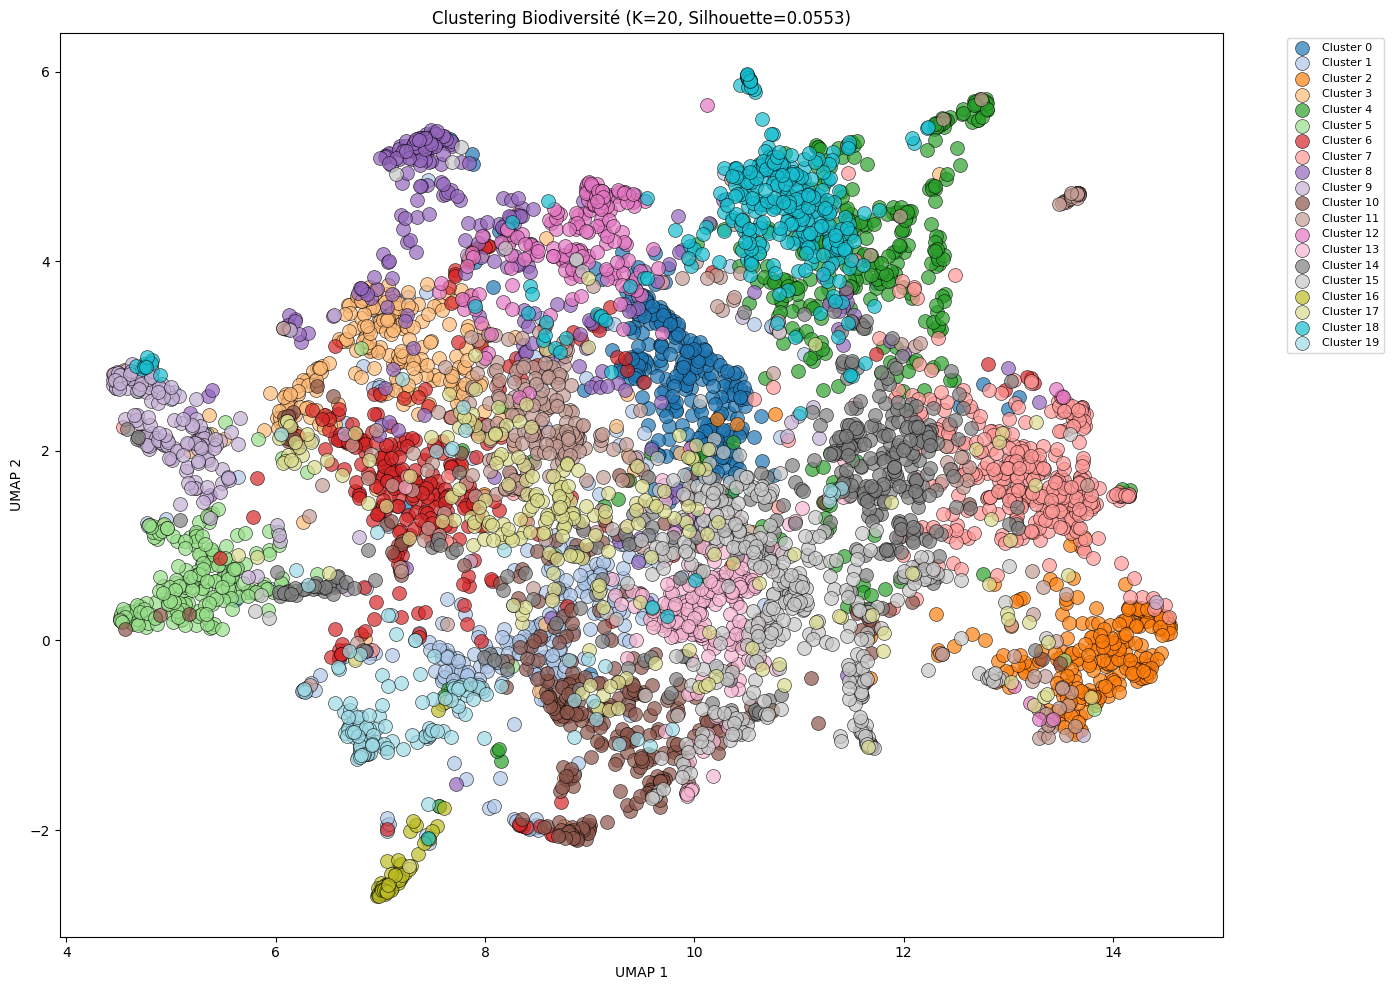

In [52]:
# ============================================================
# 6. PROJECTION 2D AVEC UMAP
# ============================================================

print("\nProjection en 2D avec UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, min_dist=0.1)
embeddings_2d = reducer.fit_transform(embeddings)

print(f"UMAP projection effectuée")

# ============================================================
# 7. VISUALISATION DES CLUSTERS
# ============================================================

plt.figure(figsize=(14, 10))
colors = plt.cm.tab20(np.linspace(0, 1, best_k))

for cluster_id in range(best_k):
    mask = final_clusters == cluster_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id}',
        s=100,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'UMAP 1')
plt.ylabel(f'UMAP 2')
plt.title(f'Clustering Biodiversité (K={best_k}, Silhouette={best_silhouette:.4f})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('clustering_biodiversite.png', dpi=300, bbox_inches='tight')
print("Graphique sauvegardé: clustering_biodiversite.png")
plt.show()

In [53]:
# ============================================================
# 8. TOP 10 PROPOSITIONS PAR CLUSTER
# ============================================================

print("\n" + "="*70)
print("TOP 10 PROPOSITIONS PAR CLUSTER")
print("="*70)

for cluster_id in range(best_k):
    cluster_mask = df['cluster'] == cluster_id
    cluster_data = df[cluster_mask].copy()
    
    # Calculer la distance de chaque point au centroïde
    cluster_embeddings = embeddings[cluster_mask]
    centroid = best_kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)

    # Récupérer les 10 points les plus proches du centroïde
    top_10_indices = np.argsort(distances)[:15]  
    top_10_propositions = cluster_data.iloc[top_10_indices]['Proposition'].values
    top_10_distances = distances[top_10_indices]

    print(f"\n CLUSTER {cluster_id} ({len(cluster_data)} propositions)")
    print("-" * 70)
    for i, (prop, dist) in enumerate(zip(top_10_propositions, top_10_distances), 1):
        print(f"{i}. {prop}")
        print(f"   Distance au centroïde: {dist:.4f}")
    print()



TOP 10 PROPOSITIONS PAR CLUSTER

 CLUSTER 0 (296 propositions)
----------------------------------------------------------------------
1. Il faut limiter les surfaces agricoles en imposant la plantation de haies.  En échange, rémunérer les agriculteurs pour services rendus
   Distance au centroïde: 0.9681
2. Il faut généraliser l’agri bio
   Distance au centroïde: 1.0404
3. Il faut favoriser l&apos;agroforesterie.
   Distance au centroïde: 1.0407
4. Il faut favoriser l&apos;élevage extensif et replanter des haies sur les espaces agropastoraux
   Distance au centroïde: 1.0743
5. Il faut imposer la semence de jachère fleurie en fonction de SAU des exploitations agricoles
   Distance au centroïde: 1.0772
6. Il faut replanter massivement de la haie bocagère et développer l’agroforesterie qui aide à la fois la biodiversité et l’agriculture.
   Distance au centroïde: 1.0891
7. Il faut réduire l’agriculture intensive qui appauvrit la terre
   Distance au centroïde: 1.1032
8. Il faut préempter

# Objets principaux des clusters (MPNet)

## Cluster 0
**Transition agroécologique des systèmes agricoles**  
(Agriculture biologique, agroforesterie, haies, élevage extensif)

## Cluster 1
**Interdiction des pratiques d’aménagement destructrices du vivant**  
(Haies, talus, urbanisation diffuse, gestion intensive des espaces)

## Cluster 2
**Éducation et sensibilisation à la biodiversité dès l’enfance**  
(École, pédagogie active, immersion dans la nature)

## Cluster 3
**Réduction des déchets et sortie du plastique jetable**  
(Consigne, recyclage, zéro déchet, emballages)

## Cluster 4
**Gestion et protection de la faune sauvage et des équilibres écologiques**  
(Régulation, chasse, cohabitation avec les espèces)

## Cluster 5
**Gestion durable de l’eau et restauration du cycle hydrologique**  
(Eaux pluviales, zones humides, nappes, sobriété)

## Cluster 6
**Renforcement des interdictions, contrôles et sanctions environnementales**  
(Pollution, police de l’environnement, fiscalité écologique)

## Cluster 7
**Gouvernance, sensibilisation et mobilisation collective pour la biodiversité**  
(Citoyens, élus, acteurs économiques, incitations)

## Cluster 8
**Interdiction des produits chimiques et matériaux nocifs pour le vivant**  
(Pesticides, engrais de synthèse, gazons artificiels)

## Cluster 9
**Protection de la biodiversité marine et des écosystèmes littoraux**  
(Pêche, transport maritime, pollution, aires marines)

## Cluster 10
**Urbanisme végétalisé et lutte contre l’artificialisation des sols**  
(Végétalisation, rénovation, limitation du béton)

## Cluster 11
**Actions écologiques transversales et sensibilisation diffuse**  
(Réintroduction d’espèces, pratiques douces, prise de conscience)

## Cluster 12
**Transition alimentaire vers des régimes durables et végétalisés**  
(Local, bio, moins de viande, lutte contre le gaspillage)

## Cluster 13
**Gestion durable et protection des forêts**  
(Fin des coupes rases, forêts anciennes, régénération naturelle)

## Cluster 14
**Préservation des espaces naturels, habitats et continuités écologiques**  
(Réensauvagement, corridors, zones humides)

## Cluster 15
**Biodiversité du quotidien et pratiques favorables chez les particuliers**  
(Jardins, haies, friches, faune de proximité)

## Cluster 16
**Réduction de la pollution lumineuse et protection de la faune nocturne**

## Cluster 17
**Actions municipales concrètes de renaturation et d’accompagnement citoyen**  
(Paillage, mares, vergers, tonte différenciée)

## Cluster 18
**Interdiction ou restriction forte de la chasse**  
(Fin des pratiques cynégétiques, protection des espèces)

## Cluster 19
**Transition vers des mobilités durables et sobriété des infrastructures**  
(Transports en commun, rail, réduction de la voiture)


In [12]:
def classify_new_texts(new_texts, model, kmeans):
    """
    Classifie de nouveaux textes avec le modèle et le classifier entraîné
    """
    new_embeddings = model.encode(new_texts)
    predictions = kmeans.predict(new_embeddings)
    return predictions

In [13]:
# Test avec un nouveau texte
new_text = ["Il faut empêcher l&apos;extension de toute zone urbaine ou artificielle sur des zones rurales ou d&apos;espaces naturels."]
predictions = classify_new_texts(new_text, model, best_kmeans)
print(f"\nNouveau texte classé dans le cluster: {predictions[0]}")


Nouveau texte classé dans le cluster: 1


In [24]:
new_text = ["Il faut développer la gastronomie végétarienne."]
predictions = classify_new_texts(new_text, model, best_kmeans)
print(f"\nNouveau texte classé dans le cluster: {predictions[0]}")


Nouveau texte classé dans le cluster: 12


In [ ]:
def semantic_similarity(text1, text2, model):
    """
    Calcule la similarité sémantique entre deux textes
    """
    from sklearn.metrics.pairwise import cosine_similarity
    
    emb1 = model.encode(text1)
    emb2 = model.encode(text2)
    similarity = cosine_similarity([emb1], [emb2])[0][0]
    return similarity


In [16]:
# Exemple: trouver le texte le plus similaire
query = "protection des espèces en danger"
similarities = [semantic_similarity(query, text, model) for text in texts]
most_similar_idx = np.argmax(similarities)
print(f"\nTexte le plus similaire à '{query}':")
print(f"  {texts[most_similar_idx]} (similarité: {similarities[most_similar_idx]:.3f})")


Texte le plus similaire à 'protection des espèces en danger':
  Il faut protéger les zones de reproduction des espèces menacées. (similarité: 0.860)


## LLM as a judge

In [ ]:
from groq import Groq
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


GROQ_API_KEY = "my_api_key" 

In [ ]:
def llm_judge_proposition(proposition, theme, api_key):
    """
    Évalue si une proposition correspond au thème assigné.
    
    Returns:
        1 si pertinente, 0 si non pertinente
    """
    client = Groq(api_key=api_key)
    
    prompt = f"""Thème assigné: {theme}

Proposition: {proposition}

La proposition correspond-elle au thème assigné?
Réponds UNIQUEMENT par 1 (pertinente) ou 0 (non pertinente)."""

    try:
        response = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "Tu réponds UNIQUEMENT par 1 ou 0."},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.3-70b-versatile",
            temperature=0,
            max_tokens=10,
        )
        
        answer = response.choices[0].message.content.strip()
        return 1 if '1' in answer else 0
        
    except Exception as e:
        print(f"Erreur: {e}")
        return None

In [56]:
# Obtain the clustering theme

def get_cluster_theme(cluster_id, df, embeddings, best_kmeans, api_key):
    """
    Demande au LLM de nommer le thème du cluster.
    """
    client = Groq(api_key=api_key)
    
    # Récupérer les 5 propositions les plus centrales
    cluster_mask = df['cluster'] == cluster_id
    cluster_embeddings = embeddings[cluster_mask]
    centroid = best_kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    
    top_10_indices = np.argsort(distances)[:10]
    top_10_props = df[cluster_mask].iloc[top_10_indices]['Proposition'].tolist()

    props_text = "\n".join([f"{i+1}. {p}" for i, p in enumerate(top_10_props)])

    prompt = f"""Voici 10 propositions représentatives d'un cluster:

{props_text}

Donne un nom de thème court (2-5 mots) qui résume ce cluster.
Réponds UNIQUEMENT avec le nom du thème."""

    try:
        response = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "Tu réponds par un thème court."},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.3-70b-versatile",
            temperature=0.3,
            max_tokens=50,
        )
        
        return response.choices[0].message.content.strip()
        
    except Exception as e:
        print(f"Erreur cluster {cluster_id}: {e}")
        return f"Cluster {cluster_id}"

In [ ]:
# Full evaluation of clusters
def evaluate_clusters(df, embeddings, best_kmeans, best_k, api_key, sample_size=50):
    """
    Évalue tous les clusters avec le LLM.
    
    Args:
        sample_size: nombre de propositions à évaluer par cluster
    
    Returns:
        DataFrame avec les résultats
    """
    results = []
    
    print(" Obtention des thèmes des clusters...")
    cluster_themes = {}
    for cluster_id in range(best_k):
        theme = get_cluster_theme(cluster_id, df, embeddings, best_kmeans, api_key)
        cluster_themes[cluster_id] = theme
        print(f"  Cluster {cluster_id}: {theme}")
    
    print(f"\n Évaluation de {sample_size} propositions par cluster...")
    
    for cluster_id in tqdm(range(best_k), desc="Clusters"):
        cluster_data = df[df['cluster'] == cluster_id]
        theme = cluster_themes[cluster_id]
        
        # Échantillonner
        sample = cluster_data.sample(min(sample_size, len(cluster_data)))
        
        for idx, row in sample.iterrows():
            proposition = row['Proposition']
            score = llm_judge_proposition(proposition, theme, api_key)
            
            if score is not None:
                results.append({
                    'cluster_id': cluster_id,
                    'theme': theme,
                    'proposition': proposition,
                    'pertinente': score
                })
    
    return pd.DataFrame(results)

In [58]:
def analyze_results(results_df):
    """
    Analyse les résultats de l'évaluation.
    """
    # Statistiques par cluster
    cluster_stats = results_df.groupby(['cluster_id', 'theme']).agg({
        'pertinente': ['mean', 'sum', 'count']
    }).round(3)
    
    cluster_stats.columns = ['taux_pertinence', 'nb_pertinentes', 'nb_total']
    cluster_stats = cluster_stats.reset_index()
    cluster_stats['taux_pertinence'] = (cluster_stats['taux_pertinence'] * 100).round(1)
    
    print("\n" + "="*80)
    print(" RÉSULTATS PAR CLUSTER")
    print("="*80)
    print(cluster_stats.to_string(index=False))
    
    # Statistiques globales
    print("\n" + "="*80)
    print(" STATISTIQUES GLOBALES")
    print("="*80)
    taux_global = results_df['pertinente'].mean() * 100
    print(f"Taux de pertinence global: {taux_global:.1f}%")
    print(f"Total propositions évaluées: {len(results_df)}")
    print(f"Propositions pertinentes: {results_df['pertinente'].sum()}")
    print(f"Propositions non pertinentes: {(1-results_df['pertinente']).sum()}")
    
    return cluster_stats

In [59]:
import matplotlib.pyplot as plt

def visualize_results(cluster_stats):
    """
    Visualise les taux de pertinence par cluster.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['#2ecc71' if x >= 80 else '#e74c3c' for x in cluster_stats['taux_pertinence']]
    
    ax.bar(cluster_stats['cluster_id'], cluster_stats['taux_pertinence'], 
           color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(y=80, color='red', linestyle='--', linewidth=2, label='Seuil 80%')
    
    ax.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
    ax.set_ylabel('Taux de pertinence (%)', fontsize=12, fontweight='bold')
    ax.set_title('Taux de pertinence par cluster', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('llm_judge_results.png', dpi=300)
    plt.show()

 Obtention des thèmes des clusters...
  Cluster 0: Agriculture et biodiversité
  Cluster 1: Protection de la biodiversité
  Cluster 2: Éducation à l'écologie
  Cluster 3: Réduction des déchets plastiques
  Cluster 4: Gestion de la faune
  Cluster 5: Gestion de l'eau
  Cluster 6: Protection de l'environnement
  Cluster 7: Sensibilisation à la biodiversité
  Cluster 8: Interdiction des pesticides
  Cluster 9: Protection de la mer
  Cluster 10: Végétalisation des villes
  Cluster 11: Protection de l'environnement
  Cluster 12: Alimentation durable et végétale
  Cluster 13: Préservation des forêts
  Cluster 14: Préservation de la biodiversité
  Cluster 15: Protection de la biodiversité
  Cluster 16: Réduction de la pollution lumineuse
  Cluster 17: Développement durable local
  Cluster 18: Interdiction de la chasse
  Cluster 19: Transports en commun durables

 Évaluation de 20 propositions par cluster...


Clusters: 100%|██████████| 20/20 [15:10<00:00, 45.55s/it]



 RÉSULTATS PAR CLUSTER
 cluster_id                               theme  taux_pertinence  nb_pertinentes  nb_total
          0         Agriculture et biodiversité            100.0              20        20
          1       Protection de la biodiversité             90.0              18        20
          2              Éducation à l'écologie             95.0              19        20
          3    Réduction des déchets plastiques             65.0              13        20
          4                 Gestion de la faune            100.0              20        20
          5                    Gestion de l'eau            100.0              20        20
          6       Protection de l'environnement            100.0              20        20
          7   Sensibilisation à la biodiversité            100.0              20        20
          8         Interdiction des pesticides             60.0              12        20
          9                Protection de la mer             90.0  

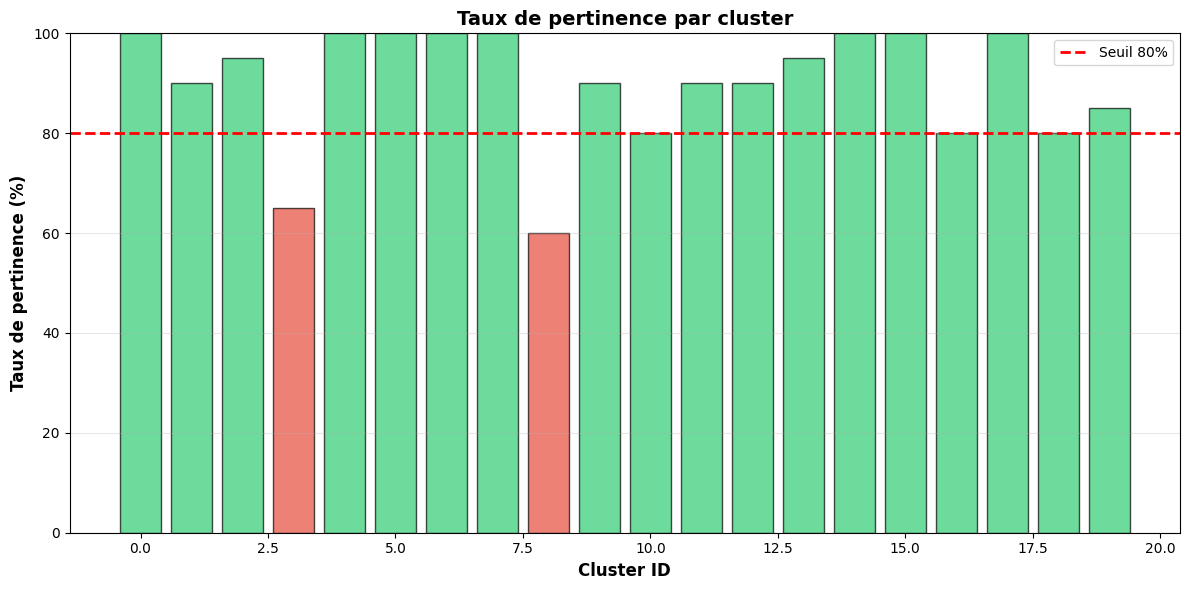


 Résultats sauvegardés!


In [60]:
# 1. Évaluer
results_df = evaluate_clusters(
    df=df,
    embeddings=embeddings,
    best_kmeans=best_kmeans,
    best_k=best_k,
    api_key=GROQ_API_KEY,
    sample_size=20  # Ajustez selon vos besoins 
)

# 2. Analyser
cluster_stats = analyze_results(results_df)

# 3. Visualiser
visualize_results(cluster_stats)

# 4. Sauvegarder
results_df.to_csv('llm_judge_results.csv', index=False)
cluster_stats.to_csv('llm_judge_cluster_stats.csv', index=False)
print("\n Résultats sauvegardés!")